In [ ]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np

from common import (
    INDEX_ORDER,
    index_colors,
    index_markers,
    transform_duckdb_index_name,
    transform_pgvector_index_name,
    apply_style,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    TITLE_FONTSIZE,
    MARKER_SIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
)


def compute_qps(metrics: dict) -> float:
    """Compute QPS from serial_latencies (seconds)."""
    latencies = metrics.get("serial_latencies")
    if not latencies:
        raise ValueError("serial_latencies is missing or empty in metrics")
    return 1.0 / np.mean(latencies)


FILTER_RATE_ORDER = [0.99, 0.9, 0.5, 0.1, 0.01]

DATASET_ORDER = [
    "Medium OpenAI (1536dim, 500K)",
    "Medium Cohere (768dim, 1M)",
]

DATASET_TITLES = {
    "Medium OpenAI (1536dim, 500K)": "OpenAI (n=500K, d=1536)",
    "Medium Cohere (768dim, 1M)": "Cohere (n=1M, d=768)",
}

# ---------------------------------------------------------------------------
# 1. Load all result JSONs
# ---------------------------------------------------------------------------
records = []

duckdb_results_dir = pathlib.Path("../experiments/results/index_filtered_search_selectivity/DuckDB")
duckdb_json_files = sorted(duckdb_results_dir.glob("*.json"))

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        custom = case_cfg.get("custom_case", {})
        filter_rate = custom.get("filter_rate")
        dataset = custom.get("dataset_with_size_type")
        if filter_rate is None or dataset is None:
            continue

        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)

        index_name = transform_duckdb_index_name(db_case_cfg, global_version)

        records.append({
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "filter_rate": filter_rate,
            "dataset": dataset,
            "db_type": "DuckDB",
        })

pgvector_results_dir = pathlib.Path("../experiments/results/index_filtered_search_selectivity/pgvector")
pgvector_json_files = sorted(pgvector_results_dir.glob("*.json")) if pgvector_results_dir.exists() else []

for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        custom = case_cfg.get("custom_case", {})
        filter_rate = custom.get("filter_rate")
        dataset = custom.get("dataset_with_size_type")
        if filter_rate is None or dataset is None:
            continue

        index_name = transform_pgvector_index_name(db_case_cfg)

        records.append({
            "recall": metrics["recall"],
            "serial_qps": compute_qps(metrics),
            "index": index_name,
            "filter_rate": filter_rate,
            "dataset": dataset,
            "db_type": "pgvector",
        })

print(f"Loaded {len(records)} results from {len(duckdb_json_files)} DuckDB files and {len(pgvector_json_files)} pgvector files")
records[:3]

Loaded 550 results from 550 DuckDB files and 0 pgvector files


[{'recall': 1.0,
  'serial_qps': np.float64(5.01607495269998),
  'index': 'DuckDB',
  'filter_rate': 0.01,
  'dataset': 'Medium Cohere (768dim, 1M)',
  'db_type': 'DuckDB'},
 {'recall': 1.0,
  'serial_qps': np.float64(5.32176441353592),
  'index': 'DuckDB',
  'filter_rate': 0.1,
  'dataset': 'Medium Cohere (768dim, 1M)',
  'db_type': 'DuckDB'},
 {'recall': 1.0,
  'serial_qps': np.float64(6.2066969614717795),
  'index': 'DuckDB',
  'filter_rate': 0.5,
  'dataset': 'Medium Cohere (768dim, 1M)',
  'db_type': 'DuckDB'}]

In [8]:
# ---------------------------------------------------------------------------
# 2. Determine datasets and filter rates present in data
# ---------------------------------------------------------------------------
datasets = [ds for ds in DATASET_ORDER if any(r["dataset"] == ds for r in records)]
filter_rates = [fr for fr in FILTER_RATE_ORDER if any(r["filter_rate"] == fr for r in records)]
print(f"Datasets: {datasets}")
print(f"Filter rates: {filter_rates}")

Datasets: ['Medium OpenAI (1536dim, 500K)', 'Medium Cohere (768dim, 1M)']
Filter rates: [0.99, 0.9, 0.5, 0.1, 0.01]


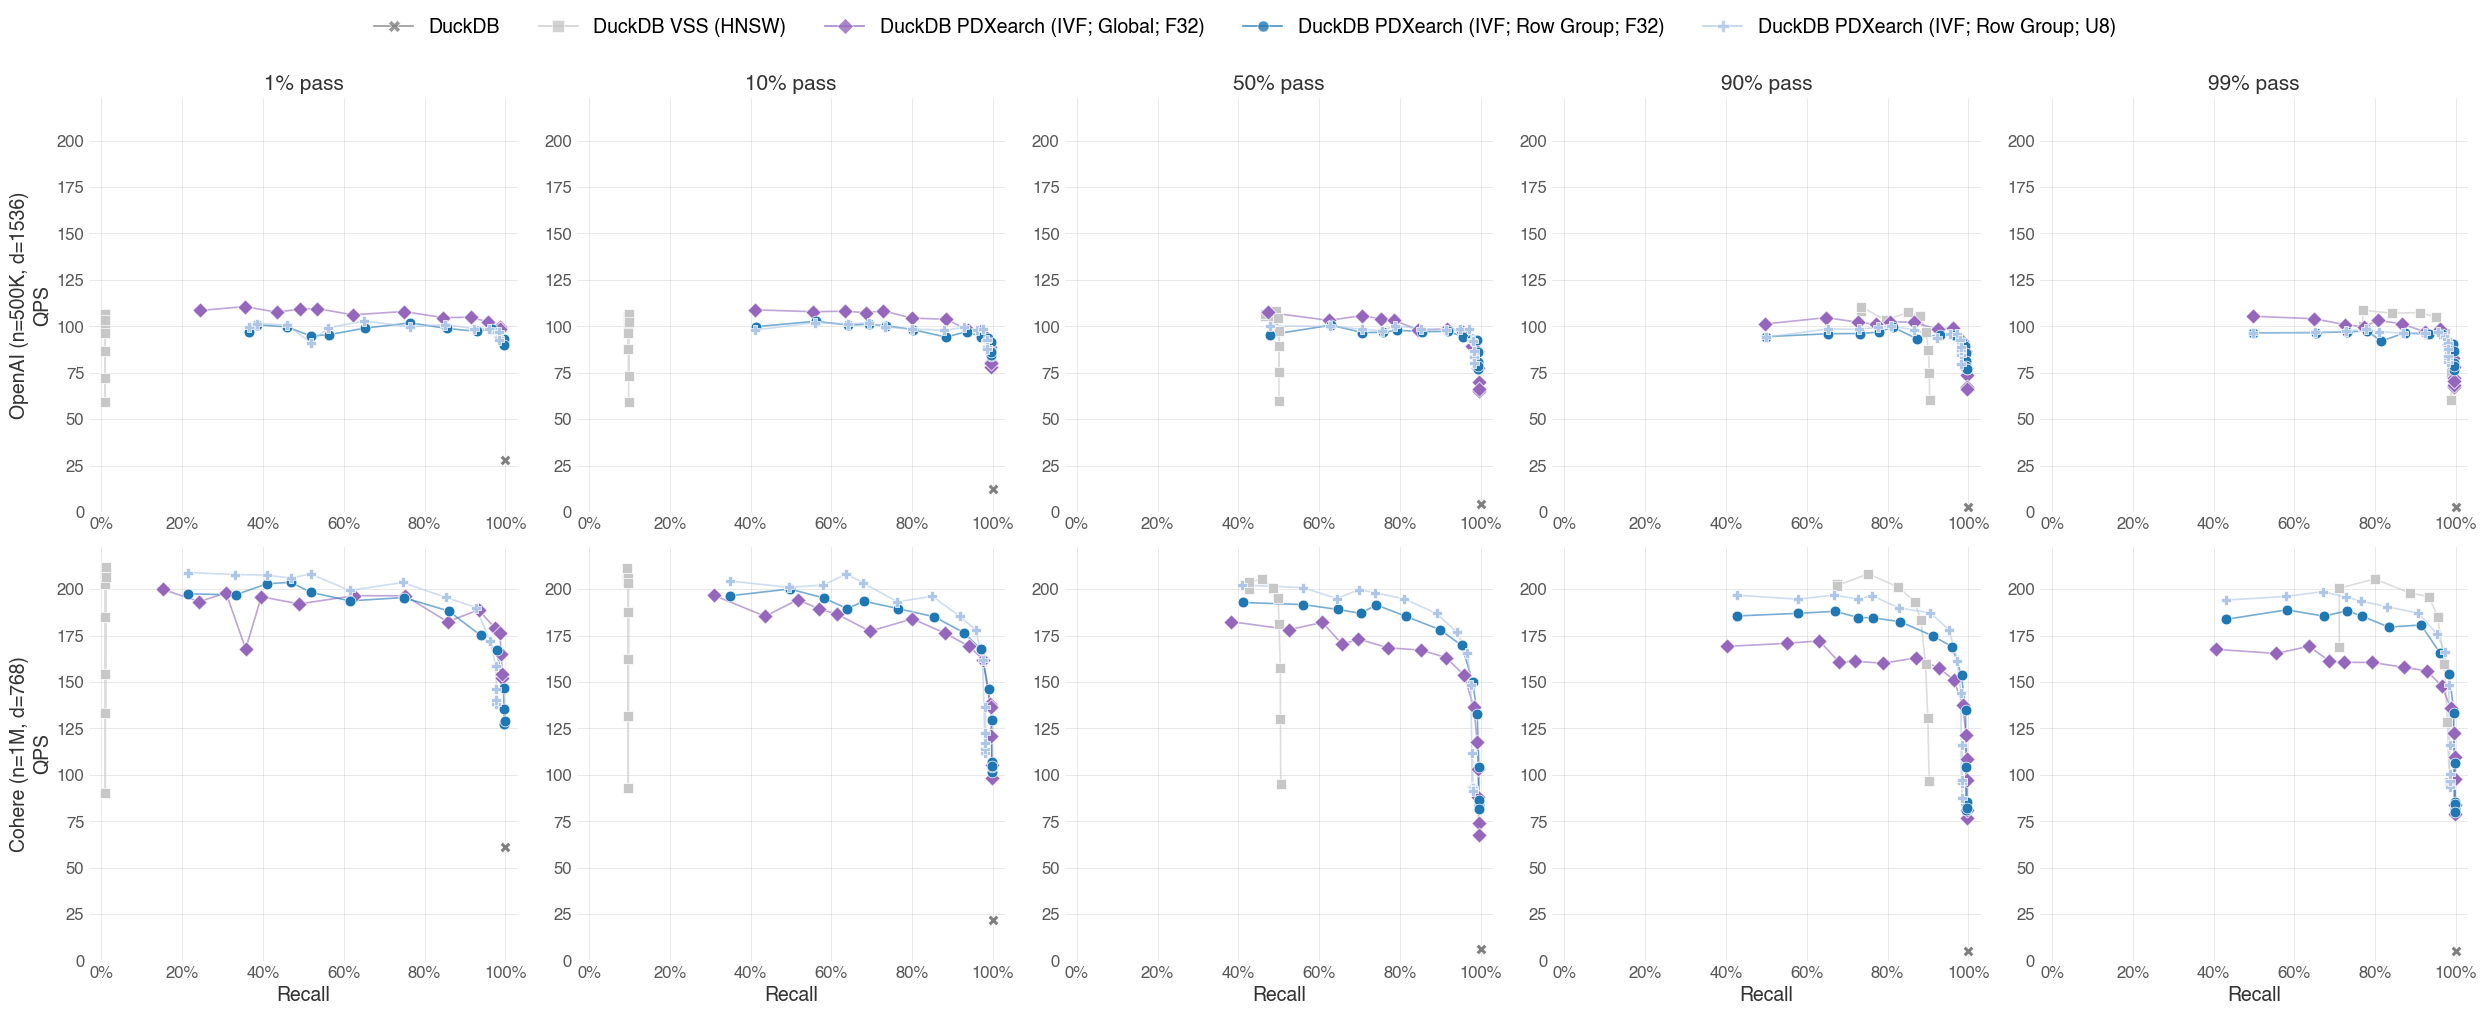

In [9]:
# ---------------------------------------------------------------------------
# 3. Scatter plot: Recall vs QPS
#    Rows = datasets, Columns = filter rates (selectivities)
# ---------------------------------------------------------------------------
from collections import defaultdict
from matplotlib.lines import Line2D

apply_style()

# Group records: (dataset, filter_rate) -> index_type -> list of (recall, qps)
grouped: dict[tuple, dict[str, list[tuple[float, float]]]] = defaultdict(lambda: defaultdict(list))

for r in records:
    grouped[(r["dataset"], r["filter_rate"])][r["index"]].append((r["recall"], r["serial_qps"]))

all_index_types = set()
for key in grouped:
    all_index_types.update(grouped[key].keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]

n_rows = len(datasets)
n_cols = len(filter_rates)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)

global_ymax = max(r["serial_qps"] for r in records) * 1.05

for row_idx, ds in enumerate(datasets):
    for col_idx, fr in enumerate(filter_rates):
        ax = axes[row_idx][col_idx]

        for index_type in all_index_types:
            points = grouped[(ds, fr)].get(index_type, [])
            if not points:
                continue

            points.sort(key=lambda p: p[0])
            recalls = [p[0] for p in points]
            qps_vals = [p[1] for p in points]

            color = index_colors.get(index_type, "#808080")
            marker = index_markers.get(index_type, "o")

            ax.scatter(recalls, qps_vals, label=index_type, color=color,
                       marker=marker, s=MARKER_SIZE, zorder=3, edgecolors='white', linewidths=0.5)
            ax.plot(recalls, qps_vals, color=color, linewidth=1.2, alpha=0.6, zorder=2)

        ds_title = DATASET_TITLES.get(ds, ds)
        if row_idx == 0:
            pass_pct = round((1 - fr) * 100)
            ax.set_title(f"{pass_pct}% pass", fontsize=TITLE_FONTSIZE, color=FONT_COLOR)

        if row_idx == n_rows - 1:
            ax.set_xlabel("Recall", fontsize=LABEL_FONTSIZE, color=FONT_COLOR)
        if col_idx == 0:
            ax.set_ylabel(f"{ds_title}\nQPS", fontsize=LABEL_FONTSIZE, color=FONT_COLOR)

        ax.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
        ax.set_axisbelow(True)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(0, global_ymax)
        ax.set_xticks([i / 5 for i in range(6)])
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

        ax.tick_params(axis='both', colors=TICK_FONTS_COLOR, length=0)
        ax.tick_params(axis='x', labelsize=TICK_FONTSIZE)
        ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)

legend_handles = []
for index_type in all_index_types:
    color = index_colors.get(index_type, "#808080")
    marker = index_markers.get(index_type, "o")
    legend_handles.append(Line2D([0], [0], color=color, marker=marker, linestyle='-',
                                  markersize=8, markeredgecolor='white', markeredgewidth=0.5,
                                  linewidth=1.2, alpha=0.8, label=index_type))

fig.legend(handles=legend_handles, loc="upper center", ncol=len(all_index_types),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.02))

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("index_filtered_search_selectivity.pdf", dpi=PLOT_DPI, bbox_inches='tight')